<a href="https://colab.research.google.com/github/chiaraco16/COVID-19-analysis/blob/main/COVID_L3_Cleaning_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📓 L3 – Structured Data Cleaning Pipeline

**Progetto:** COVID-19 Trend Analysis — Chiara Costantino (277081)

---

**Obiettivo:** Costruire una pipeline di pulizia per le tabelle del DW COVID-19.
Ogni trasformazione viene registrata nell'**AuditLog** con valori prima/dopo, rendendo il processo tracciabile e riproducibile.

### Passi della pipeline:

| Step | Tecnica | Motivazione DW |
|------|---------|----------------|
| **Rimozione OWID_** | Eliminazione aggregati non-geografici | Consistenza Dim_Location_Context |
| **Standardizzazione date** | Parsing ISO 8601 | Conformità Dim_Time |
| **Zero-imputation** | Fillna(0) per misure di flusso | MCAR — dati non registrati = zero eventi |
| **Forward-fill** | Propagazione valori cumulativi | MAR — le misure cumulative non decrescono |
| **Validazione numerica** | Clip valori negativi | Validità ISO 25012 |
| **Audit logging** | Ogni modifica registrata con before/after | Lineage & compliance |

### Case study:
-  **Case A**: `Epidemic_Trend` — tabella fatti principale (new_cases, new_deaths, new_tests)
-  **Case B**: `Prevention_Measures` — misure cumulative (people_vaccinated, people_fully_vaccinated, total_boosters)


##  0. Connessione a Google Drive

In [6]:
# Monto Google Drive per leggere i file del progetto
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Percorsi dei file di input (OWID) e di output (CSV puliti + log di audit)
#Percorsi
BASE_PATH = '/content/drive/MyDrive/Covid-19 Analysis/'
# Cartella base su Google Drive contenente i dati del progetto
DATA_FILE = BASE_PATH + 'owid-covid-data-2.xlsx'
# File sorgente OWID
OUTPUT_EPIDEMIC    = BASE_PATH + 'L3_epidemic_trend_clean.csv'
OUTPUT_PREVENTION  = BASE_PATH + 'L3_prevention_measures_clean.csv'
OUTPUT_LOCATIONS   = BASE_PATH + 'L3_locations_clean.csv'
OUTPUT_AUDIT_A     = BASE_PATH + 'L3_epidemic_audit_log.csv'
OUTPUT_AUDIT_B     = BASE_PATH + 'L3_prevention_audit_log.csv'
OUTPUT_AUDIT_SUM_A = BASE_PATH + 'L3_epidemic_audit_summary.csv'
OUTPUT_AUDIT_SUM_B = BASE_PATH + 'L3_prevention_audit_summary.csv'

##  1. Librerie

In [8]:
# Installo le librerie usate nel notebook
!pip install scikit-learn scipy --quiet

In [9]:
# Importo le librerie del notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from datetime import datetime
from copy import deepcopy
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from scipy import stats

# Impostazioni di visualizzazione
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
np.random.seed(42)

print('Librerie caricate')

Librerie caricate


##  2. Caricamento Dataset OWID

Il file `owid-covid-data-2.xlsx` contiene dati COVID-19 da Our World in Data (OWID):
- **229.218 righe** × **67 colonne**
- Granularità giornaliera per paese, dal 2020 al 2024
- Include sia paesi reali sia aggregati geografici (prefisso `OWID_`)


In [10]:
# Carico il dataset OWID dal file Excel su Google Drive (dati COVID giornalieri).
path = BASE_PATH + 'owid-covid-data-2.xlsx'
print(f' File trovato: {path}')

raw_df = pd.read_excel(path, engine='openpyxl', parse_dates=['date'])

print(f'Dataset caricato: {raw_df.shape[0]:,} righe × {raw_df.shape[1]} colonne')

 File trovato: /content/drive/MyDrive/Covid-19 Analysis/owid-covid-data-2.xlsx
Dataset caricato: 309,942 righe × 67 colonne


In [11]:
# Divido il dataset originale nelle 3 tabelle del modello riconciliato
# (Locations = attributi paese, Epidemic_Trend e Prevention_Measures = misure giornaliere)
# Partizione raw_df nelle 3 tabelle del Reconciled DB
#
# Il file OWID è un unico dataset "flat". Lo partizioniamo in 3 tabelle
# normalizzate che corrispondono alla struttura del progetto:
#   • Locations       → una riga per paese (attributi statici)
#   • Epidemic_Trend  → una riga per (paese, data): misure di flusso
#   • Prevention_Measures → una riga per (paese, data): vaccinazioni e politiche


# Attributi statici della dimensione (cfr. Dim_Location_Context nel report)
LOCATION_COLS = [
    'iso_code', 'continent', 'location',
    'population', 'population_density', 'median_age',
    'gdp_per_capita', 'hospital_beds_per_thousand',
    'human_development_index'
]

# Misure epidemiche (fenomeno osservato)
EPIDEMIC_COLS = [
    'iso_code', 'date',
    'new_cases', 'total_cases', 'new_deaths', 'total_deaths'
]

# Misure di prevenzione/risposta (test, vaccinazioni, politiche).
PREVENTION_COLS = [
    'iso_code', 'date',
    'people_vaccinated', 'new_tests', 'stringency_index'
]

def safe_cols(cols, df):
    """Restituisce solo le colonne presenti nel DataFrame."""
    return [c for c in cols if c in df.columns]

#Rimuovo aggregati OWID_ (non sono paesi reali)
mask_real = ~raw_df['iso_code'].str.startswith('OWID_', na=False)
df_real   = raw_df[mask_real].copy()

#Creo le 3 tabelle
locations_df = (df_real[safe_cols(LOCATION_COLS, df_real)]
                .drop_duplicates(subset=['iso_code'])
                .reset_index(drop=True))

epidemic_df  = df_real[safe_cols(EPIDEMIC_COLS, df_real)].reset_index(drop=True)

prevention_df = df_real[safe_cols(PREVENTION_COLS, df_real)].reset_index(drop=True)

# Alias usato in alcune celle: national_df = locations_df
national_df = locations_df

print(f'locations_df:       {locations_df.shape[0]:>6,} righe × {locations_df.shape[1]:>2} colonne')
print(f'epidemic_df:        {epidemic_df.shape[0]:>6,} righe × {epidemic_df.shape[1]:>2} colonne')
print(f'prevention_df:      {prevention_df.shape[0]:>6,} righe × {prevention_df.shape[1]:>2} colonne')
print(f'Paesi unici:  {locations_df["iso_code"].nunique()}')
print(f'Periodo:      {epidemic_df["date"].min().date()} → {epidemic_df["date"].max().date()}')


locations_df:          171 righe ×  9 colonne
epidemic_df:        284,692 righe ×  6 colonne
prevention_df:      284,692 righe ×  5 colonne
Paesi unici:  171
Periodo:      2020-01-01 → 2024-08-14


## 3. Costruzione Tabelle Riconciliate

Prima della pulizia, partiziono il dataset flat in **3 tabelle normalizzate**
che corrispondono alla struttura del Reconciled DB del progetto:

| Tabella | Chiave | Descrizione |
|---------|--------|-------------|
| `Locations` | `iso_code` | Attributi geografici/demografici per paese |
| `Epidemic_Trend` | `iso_code, date` | Misure di flusso epidemiologico (new_*) |
| `Prevention_Measures` | `iso_code, date` | Misure cumulative (vaccinations, boosters) |


In [12]:
# Ricreo le 3 tabelle partendo dal grezzo: la pulizia degli OWID_* avviene nella pipeline
# Colonne per ogni tabella — ristrette allo schema del report

# Attributi statici per paese — popolano Dim_Location_Context nel DW
LOCATION_COLS = [
    'iso_code', 'continent', 'location',
    'population', 'population_density', 'median_age',
    'gdp_per_capita', 'hospital_beds_per_thousand',
    'human_development_index'
]

# Misure epidemiche (flusso + cumulate) — Epidemic_Trend
EPIDEMIC_COLS = [
    'iso_code', 'date',
    'new_cases', 'total_cases', 'new_deaths', 'total_deaths'
]

# Misure di prevenzione — Prevention_Measures.
# new_tests è qui
PREVENTION_COLS = [
    'iso_code', 'date',
    'people_vaccinated', 'new_tests', 'stringency_index'
]

# Filtra solo colonne esistenti
def safe_cols(cols, df):
    return [c for c in cols if c in df.columns]

#Creo tabella Locations (una riga per paese)
loc_cols = safe_cols(LOCATION_COLS, raw_df)
locations_raw = (raw_df[loc_cols]
                 .drop_duplicates(subset=['iso_code'])
                 .reset_index(drop=True))

#Creo tabella Epidemic_Trend (una riga per paese×data)
ep_cols = safe_cols(EPIDEMIC_COLS, raw_df)
epidemic_raw = raw_df[ep_cols].copy().reset_index(drop=True)

#Creo tabella Prevention_Measures (una riga per paese×data)
prev_cols = safe_cols(PREVENTION_COLS, raw_df)
prevention_raw = raw_df[prev_cols].copy().reset_index(drop=True)

print(f'Locations:          {locations_raw.shape[0]:,} righe × {locations_raw.shape[1]} colonne')
print(f'Epidemic_Trend:     {epidemic_raw.shape[0]:,} righe × {epidemic_raw.shape[1]} colonne')
print(f'Prevention_Measures:{prevention_raw.shape[0]:,} righe × {prevention_raw.shape[1]} colonne')


Locations:          184 righe × 9 colonne
Epidemic_Trend:     309,942 righe × 6 colonne
Prevention_Measures:309,942 righe × 5 colonne


## 4. Framework: AuditLog + CleaningPipeline

Il framework è composto da due classi:

- **`AuditLog`** — registra ogni modifica a livello di cella con: step, colonna, riga, valore prima, valore dopo, motivazione
- **`CleaningPipeline`** — pipeline modulare a step concatenabili; ogni step chiama l'AuditLog

Questo approccio garantisce:
- **Tracciabilità**:
- **Riproducibilità**:
- **Conformità**:

In [13]:
# Due classi che gestiscono la pulizia dei dati:
#  - AuditLog: registra ogni modifica fatta (per tracciabilita)
#  - CleaningPipeline: applica gli step di pulizia in sequenza
class AuditLog:
    """
    Registra ogni trasformazione di pulizia applicata al dataset.
    Ogni entry cattura: step, colonna, indice riga, valore prima, valore dopo, timestamp.
    """

    def __init__(self):
        self._entries = []
        # Lista interna

    def log(self, step, col, idx, before, after, reason=''):
        """Registra una singola trasformazione."""
        self._entries.append({
            'step'      : step,
            'column'    : col,
            'row_index' : idx,
            'before'    : str(before),
            'after'     : str(after),
            'reason'    : reason,
            'timestamp' : datetime.now().isoformat()
        })

    def log_batch(self, step, col, mask,
                  before_series, after_series, reason=''):
        """Registra modifiche multiple (step vettorizzato)."""
        for idx in mask[mask].index:
            self.log(step, col, idx,
                     before_series.get(idx, 'N/A'),
                     after_series.get(idx, 'N/A'),
                     reason)

    def to_df(self):
        """Converte l'audit log in DataFrame pandas."""
        return pd.DataFrame(self._entries)

    def summary(self):
        """Riepilogo aggregato per step."""
        if not self._entries:
            return pd.DataFrame()
        df = self.to_df()
        return (df.groupby('step')
                  .agg(modifiche=('row_index','count'),
                       colonne_modificate=('column', lambda x: ', '.join(sorted(x.unique()))))
                  .reset_index()
                  .sort_values('modifiche', ascending=False))

    def __len__(self):
        return len(self._entries)


class CleaningPipeline:
    """
    Pipeline modulare e verificabile per la pulizia di tabelle DW.
    Ogni step è una funzione registrata che modifica clean_df e logga in AuditLog.
    """

    def __init__(self, df, table_name, pk_col=None):
        self.original_df = df.copy()
        self.clean_df    = df.copy()
        self.table_name  = table_name
        self.pk_col      = pk_col
        self.audit       = AuditLog()
        self._steps      = []

    # Step 1: Rimozione righe OWID_
    def remove_owid_aggregates(self, iso_col='iso_code'):
        """
        Rimuove le righe con prefisso OWID_ dalla colonna iso_code.
        Motivazione: i codici OWID_ rappresentano aggregati regionali/globali (es. OWID_WRL),
        non paesi reali. Includerli nel DW violerebbe la consistenza della Dim_Location_Context.
        """
        step = 'remove_owid_aggregates'
        mask = self.clean_df[iso_col].str.startswith('OWID_', na=False)
        removed = mask.sum()

        for idx in self.clean_df[mask].index:
            iso = self.clean_df.at[idx, iso_col]
            self.audit.log(step, iso_col, idx, iso, 'ELIMINATA',
                           reason=f'Codice OWID_ = aggregato non-geografico')

        self.clean_df = self.clean_df[~mask].reset_index(drop=True)
        self._steps.append(step)
        print(f'  [{step}] → {removed:,} righe rimosse con prefisso OWID_')
        return self

    #Step 2: Standardizzazione date
    def parse_dates(self, date_col):
        """
        Converte la colonna date in tipo datetime64 e formato ISO 8601 (YYYY-MM-DD).
        Motivazione: la colonna date deve essere conforme al formato atteso da Dim_Time.
        """
        step = 'parse_dates'
        before = self.clean_df[date_col].astype(str)
        self.clean_df[date_col] = pd.to_datetime(self.clean_df[date_col], errors='coerce')
        after = self.clean_df[date_col].astype(str)

        mask = before != after
        self.audit.log_batch(step, date_col, mask, before, after,
                             reason='Conversione a datetime64 ISO 8601')
        self._steps.append(step)
        invalid_dates = self.clean_df[date_col].isna().sum()
        print(f'  [{step}] → date convertite; {invalid_dates} date non parsabili (NaT)')
        return self

    #Step 3: Zero-imputation per misure di flusso
    def zero_impute_flow_measures(self, cols):
        """
        Imputa i valori mancanti con 0 per le misure di flusso (new_*).
        Motivazione: i dati OWID mancanti per new_cases/new_deaths in un giorno
        indicano assenza di segnalazione, interpretabile come zero eventi (MCAR).
        NON si usa per misure cumulative (total_*) o di stock.
        """
        step = 'zero_impute_flow_measures'
        total_filled = 0
        for col in cols:
            if col not in self.clean_df.columns:
                continue
            mask = self.clean_df[col].isna()
            before = self.clean_df[col].copy()
            self.clean_df[col] = self.clean_df[col].fillna(0.0)
            after = self.clean_df[col]
            self.audit.log_batch(step, col, mask, before, after,
                                 reason='Flusso giornaliero non segnalato → 0 (MCAR)')
            total_filled += mask.sum()

        self._steps.append(step)
        print(f'  [{step}] → {total_filled:,} celle imputate con 0 in {len(cols)} colonne')
        return self

    #Step 4: Forward-fill per misure cumulative
    def forward_fill_cumulative(self, cols, group_col='iso_code'):
        """
        Applica forward-fill per le misure cumulative, raggruppate per paese.
        Motivazione: le misure cumulative (total_vaccinations, people_vaccinated, ecc.)
        non possono diminuire nel tempo. I gap NaN dopo il primo valore valido
        indicano assenza di aggiornamento (MAR — il valore precedente è la migliore stima).
        I NaN iniziali (prima dell'inizio dei vaccini) restano NaN e vengono poi
        imputati a 0 separatamente per i paesi che non hanno mai iniziato campagne.
        """
        step = 'forward_fill_cumulative'
        total_filled = 0
        for col in cols:
            if col not in self.clean_df.columns:
                continue
            before = self.clean_df[col].copy()
            self.clean_df[col] = (self.clean_df
                                  .groupby(group_col)[col]
                                  .transform(lambda s: s.ffill()))
            mask = before.isna() & self.clean_df[col].notna()
            after = self.clean_df[col]
            self.audit.log_batch(step, col, mask, before, after,
                                 reason='Misura cumulativa: ffill per gruppo iso_code (MAR)')
            total_filled += mask.sum()

        self._steps.append(step)
        print(f'  [{step}] → {total_filled:,} celle propagate in {len(cols)} colonne cumulative')
        return self

    #Step 5: Zero-fill per NaN residui post-ffill (leading NaN)
    def zero_fill_leading_nans(self, cols):
        """
        Dopo il forward-fill, i NaN iniziali (prima del primo valore valido) restano.
        Per i vaccini: prima del 2021 non esistevano vaccini → 0 è corretto.
        Questo step completa la pulizia imputando 0 ai NaN rimasti.
        """
        step = 'zero_fill_leading_nans'
        total_filled = 0
        for col in cols:
            if col not in self.clean_df.columns:
                continue
            mask = self.clean_df[col].isna()
            before = self.clean_df[col].copy()
            self.clean_df[col] = self.clean_df[col].fillna(0.0)
            after = self.clean_df[col]
            self.audit.log_batch(step, col, mask, before, after,
                                 reason='NaN iniziale pre-vaccino → 0 (MNAR: vaccini non esistevano)')
            total_filled += mask.sum()

        self._steps.append(step)
        print(f'  [{step}] → {total_filled:,} NaN iniziali sostituiti con 0')
        return self

    #Step 6: Clip valori negativi
    def clip_negatives(self, cols, min_val=0.0):
        """
        Imposta a 0 i valori negativi nelle colonne numeriche specificate.
        Motivazione: conteggi come new_cases, new_deaths non possono essere negativi.
        I valori negativi sono correzioni retroattive nei dati OWID → sostituiti con 0.
        """
        step = 'clip_negatives'
        total_clipped = 0
        for col in cols:
            if col not in self.clean_df.columns:
                continue
            mask = self.clean_df[col].fillna(0) < min_val
            before = self.clean_df[col].copy()
            self.clean_df.loc[mask, col] = min_val
            after = self.clean_df[col]
            self.audit.log_batch(step, col, mask, before, after,
                                 reason=f'Valore negativo cliped a {min_val} (correzione OWID retroattiva)')
            total_clipped += mask.sum()

        self._steps.append(step)
        print(f'  [{step}] → {total_clipped:,} valori negativi cliped a {min_val}')
        return self

    #Step 7: Deduplicazione per chiave composta
    def deduplicate(self, key_cols, keep='first'):
        """
        Rimuove righe duplicate basandosi sulla chiave composta specificata.
        Per Epidemic_Trend e Prevention_Measures la chiave è (iso_code, date).
        """
        step = 'deduplicate'
        before_n = len(self.clean_df)
        dup_mask = self.clean_df.duplicated(subset=key_cols, keep=keep)
        n_dups = dup_mask.sum()

        for idx in self.clean_df[dup_mask].index:
            self.audit.log(step, str(key_cols), idx,
                           'duplicato', 'ELIMINATA',
                           reason=f'Riga duplicata su chiave {key_cols}')

        self.clean_df = self.clean_df[~dup_mask].reset_index(drop=True)
        self._steps.append(step)
        print(f'  [{step}] → {n_dups} righe duplicate rimosse (da {before_n:,} a {len(self.clean_df):,})')
        return self

    #Riepilogo pipeline
    def summary(self):
        """Stampa un riepilogo della pipeline eseguita."""
        print(f'\n RIEPILOGO PIPELINE — {self.table_name}')
        print(f'   Righe originali:  {len(self.original_df):,}')
        print(f'   Righe pulite:     {len(self.clean_df):,}')
        print(f'   Step eseguiti:    {len(self._steps)}')
        print(f'   Audit entries:    {len(self.audit):,}')
        print()
        if len(self.audit) > 0:
            print(self.audit.summary().to_string(index=False))
        return self

print('AuditLog e CleaningPipeline definiti')

AuditLog e CleaningPipeline definiti


## 5. CASE A — Epidemic_Trend Cleaning

La tabella `Epidemic_Trend` contiene misure di **flusso** giornaliere (new_cases, new_deaths, new_tests).

### Strategia di pulizia:

| Problema | Strategia | Motivazione |
|----------|-----------|-------------|
| Righe OWID_ | Eliminazione | Aggregati non geografici |
| NaN in new_cases / new_deaths | Zero-imputation | MCAR: assenza di segnalazione = 0 eventi |
| Valori negativi | Clip a 0 | Correzioni OWID retroattive |
| Righe duplicate (iso_code, date) | Deduplicazione | Integrità chiave composta |


>  i valori estremi (es. new_cases > 1.000.000 in USA a gennaio 2022)
> sono **reali**, non errori.


In [14]:
# Pipeline Epidemic_Trend: applico gli step di pulizia in sequenza e stampo il riepilogo
# total_cases e total_deaths non vengono riempiti -> restano NULL
# la monotonicita delle cumulate viene imposta dal cummax nell'ETL (L5).
FLOW_MEASURES = ['new_cases', 'new_deaths']
# Misure giornaliere: NaN = giorno non segnalato -> zero eventi

# Tutte le misure numeriche da validare per valori negativi
NUMERIC_COLS_A = ['new_cases', 'total_cases', 'new_deaths', 'total_deaths']

#Pipeline Case A
print(' Avvio pipeline di pulizia: Epidemic_Trend')
print('\u2500' * 55)

pipe_epidemic = (
    CleaningPipeline(epidemic_raw, 'Epidemic_Trend', pk_col=['iso_code','date'])

    .remove_owid_aggregates(iso_col='iso_code')
    # Step 1: Rimuovo righe OWID_ (aggregati regionali/mondiali non geografici)

    .parse_dates('date')
    # Step 2: Standardizzo la colonna date in formato datetime64 ISO 8601

    .clip_negatives([col for col in NUMERIC_COLS_A if col in epidemic_raw.columns])
    # Step 3: Sostituisco i valori negativi con 0 (correzioni retroattive OWID)

    .zero_impute_flow_measures([col for col in FLOW_MEASURES if col in epidemic_raw.columns])
    # Step 4: Imputa i NaN nelle misure di flusso (new_cases, new_deaths) con 0

    .deduplicate(['iso_code', 'date'], keep='first')
    # Step 5: Rimuovo righe duplicate per chiave (iso_code, date)
)

pipe_epidemic.summary()

 Avvio pipeline di pulizia: Epidemic_Trend
───────────────────────────────────────────────────────
  [remove_owid_aggregates] → 25,250 righe rimosse con prefisso OWID_
  [parse_dates] → date convertite; 0 date non parsabili (NaT)
  [clip_negatives] → 0 valori negativi cliped a 0.0
  [zero_impute_flow_measures] → 7,417 celle imputate con 0 in 2 colonne
  [deduplicate] → 394 righe duplicate rimosse (da 284,692 a 284,298)

 RIEPILOGO PIPELINE — Epidemic_Trend
   Righe originali:  309,942
   Righe pulite:     284,298
   Step eseguiti:    5
   Audit entries:    33,061

                     step  modifiche    colonne_modificate
   remove_owid_aggregates      25250              iso_code
zero_impute_flow_measures       7417 new_cases, new_deaths
              deduplicate        394  ['iso_code', 'date']


In [22]:
# Salvo la tabella pulita e i log di audit su CSV
# Salva output Case A

pipe_epidemic.clean_df.to_csv(OUTPUT_EPIDEMIC, index=False)
pipe_epidemic.audit.to_df().to_csv(OUTPUT_AUDIT_A, index=False)
pipe_epidemic.audit.summary().to_csv(OUTPUT_AUDIT_SUM_A, index=False)

print(f'Epidemic_Trend pulita → {OUTPUT_EPIDEMIC}')
print(f' Audit log dettagliato → {OUTPUT_AUDIT_A}')
print(f'Audit summary         → {OUTPUT_AUDIT_SUM_A}')
print()


audit_a = pipe_epidemic.audit.to_df()

Epidemic_Trend pulita → /content/drive/MyDrive/Covid-19 Analysis/L3_epidemic_trend_clean.csv
 Audit log dettagliato → /content/drive/MyDrive/Covid-19 Analysis/L3_epidemic_audit_log.csv
Audit summary         → /content/drive/MyDrive/Covid-19 Analysis/L3_epidemic_audit_summary.csv



###  Analisi Post-Pulizia: Epidemic_Trend

Verifica visiva della distribuzione delle misure principali dopo la pulizia.


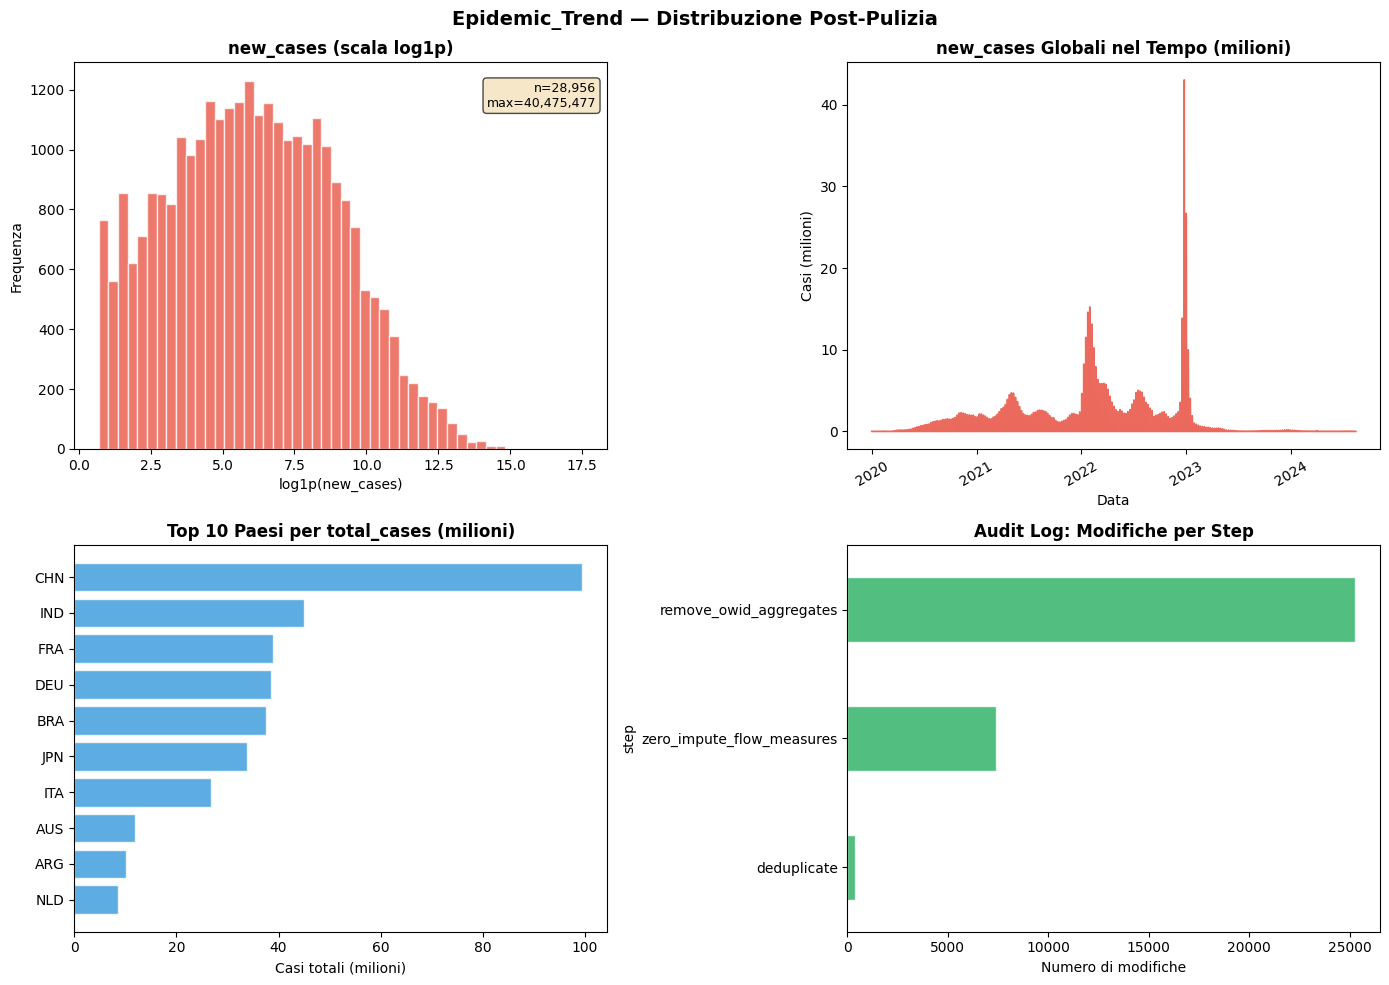

In [16]:
# Grafici di controllo dopo la pulizia di Epidemic_Trend
# Visualizzazione distribuzione post-pulizia
clean_ep = pipe_epidemic.clean_df

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Epidemic_Trend — Distribuzione Post-Pulizia', fontsize=14, fontweight='bold')

# 1. Distribuzione new_cases (scala log)
ax = axes[0, 0]
col = 'new_cases'
if col in clean_ep.columns:
    vals = clean_ep[col].replace(0, np.nan).dropna()
    ax.hist(np.log1p(vals), bins=50, color='#e74c3c', alpha=0.75, edgecolor='white')
    ax.set_title('new_cases (scala log1p)', fontweight='bold')
    ax.set_xlabel('log1p(new_cases)')
    ax.set_ylabel('Frequenza')
    ax.text(0.98, 0.95, f'n={len(vals):,}\nmax={vals.max():,.0f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.7))

# 2. Serie temporale new_cases globali
ax = axes[0, 1]
if 'new_cases' in clean_ep.columns and 'date' in clean_ep.columns:
    daily = (clean_ep.groupby('date')['new_cases']
             .sum()
             .reset_index()
             .sort_values('date'))
    ax.plot(daily['date'], daily['new_cases'] / 1e6, color='#e74c3c', linewidth=1.2, alpha=0.8)
    ax.set_title('new_cases Globali nel Tempo (milioni)', fontweight='bold')
    ax.set_xlabel('Data')
    ax.set_ylabel('Casi (milioni)')
    ax.tick_params(axis='x', rotation=30)
    ax.fill_between(daily['date'], daily['new_cases'] / 1e6, alpha=0.15, color='#e74c3c')

# 3. Top 10 paesi per total_cases
ax = axes[1, 0]
if 'total_cases' in clean_ep.columns:
    top10 = (clean_ep.groupby('iso_code')['total_cases']
             .max()
             .nlargest(10)
             .reset_index())
    ax.barh(top10['iso_code'], top10['total_cases'] / 1e6,
            color='#3498db', alpha=0.8, edgecolor='white')
    ax.set_title('Top 10 Paesi per total_cases (milioni)', fontweight='bold')
    ax.set_xlabel('Casi totali (milioni)')
    ax.invert_yaxis()

# 4. Audit log: modifiche per step
ax = axes[1, 1]
if len(pipe_epidemic.audit) > 0:
    audit_sum_a = pipe_epidemic.audit.summary().set_index('step')
    audit_sum_a['modifiche'].sort_values().plot(
        kind='barh', ax=ax, color='#27ae60', alpha=0.8, edgecolor='white')
    ax.set_title('Audit Log: Modifiche per Step', fontweight='bold')
    ax.set_xlabel('Numero di modifiche')
else:
    ax.text(0.5, 0.5, 'Nessuna modifica registrata', ha='center', va='center',
            transform=ax.transAxes, fontsize=11)
    ax.set_title('Audit Log', fontweight='bold')

plt.tight_layout()
plt.savefig(BASE_PATH + 'L3_epidemic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. CASE B — Prevention_Measures Cleaning

La tabella `Prevention_Measures` contiene misure **cumulative** di vaccinazione e politiche.

### Strategia di pulizia:

| Problema | Strategia | Motivazione |
|----------|-----------|-------------|
| Righe OWID_ | Eliminazione | Aggregati non geografici |
| NaN in dati cumulativi post-primo valore | Forward-fill per paese | MAR: il valore precedente è la migliore stima |
| NaN iniziali (pre-vaccino) | Zero-fill | MNAR: i vaccini non esistevano prima del 2021 |
| Valori negativi in new_vaccinations | Clip a 0 | Correzioni retroattive OWID |

> **Meccanismo MNAR**: i dati di vaccinazione sono mancanti prima del 2021 perché
> i vaccini non erano stati approvati. Questo è **Missing Not At Random**: la mancanza
> dipende direttamente dal valore (vaccini = 0 perché non esistevano), non da errori di raccolta dati.



In [17]:
# Pipeline Prevention_Measures: stessi step adattati a test/vaccini/stringency
# riempio solo people_vaccinated
# stringency_index resta NULL dove non tracciato
CUMULATIVE_MEASURES = ['people_vaccinated']   # solo people_vaccinated viene riempito

# Misura di flusso giornaliera: new_tests (NaN = giorno non segnalato -> 0)
FLOW_PREV = ['new_tests']

# Pipeline Case B
print(' Avvio pipeline di pulizia: Prevention_Measures')
print('\u2500' * 55)

pipe_prevention = (
    CleaningPipeline(prevention_raw, 'Prevention_Measures', pk_col=['iso_code','date'])

    .remove_owid_aggregates(iso_col='iso_code')
    # Step 1: Rimuovo righe OWID_ (aggregati non geografici)

    .parse_dates('date')
    # Step 2: Standardizzo la colonna date

    .clip_negatives([col for col in FLOW_PREV if col in prevention_raw.columns])
    # Step 3: Valori negativi in new_tests -> 0

    .forward_fill_cumulative(
        [col for col in CUMULATIVE_MEASURES if col in prevention_raw.columns],
        group_col='iso_code'
    )
    # Step 4: Forward-fill per paese SOLO su people_vaccinated (MAR)

    .zero_fill_leading_nans(
        [col for col in CUMULATIVE_MEASURES if col in prevention_raw.columns]
    )
    # Step 5: I NaN iniziali pre-vaccino di people_vaccinated -> 0
    #

    .zero_impute_flow_measures(
        [col for col in FLOW_PREV if col in prevention_raw.columns]
    )
    # Step 6: NaN in new_tests -> 0 (giorno senza test segnalati)

    .deduplicate(['iso_code', 'date'], keep='first')
    # Step 7: Rimuovo righe duplicate per chiave (iso_code, date)
)

pipe_prevention.summary()

 Avvio pipeline di pulizia: Prevention_Measures
───────────────────────────────────────────────────────
  [remove_owid_aggregates] → 25,250 righe rimosse con prefisso OWID_
  [parse_dates] → date convertite; 0 date non parsabili (NaT)
  [clip_negatives] → 0 valori negativi cliped a 0.0
  [forward_fill_cumulative] → 149,738 celle propagate in 1 colonne cumulative
  [zero_fill_leading_nans] → 86,758 NaN iniziali sostituiti con 0
  [zero_impute_flow_measures] → 231,205 celle imputate con 0 in 1 colonne
  [deduplicate] → 394 righe duplicate rimosse (da 284,692 a 284,298)

 RIEPILOGO PIPELINE — Prevention_Measures
   Righe originali:  309,942
   Righe pulite:     284,298
   Step eseguiti:    7
   Audit entries:    493,345

                     step  modifiche   colonne_modificate
zero_impute_flow_measures     231205            new_tests
  forward_fill_cumulative     149738    people_vaccinated
   zero_fill_leading_nans      86758    people_vaccinated
   remove_owid_aggregates      25250    

In [23]:
# Salvo Prevention_Measures pulita e i relativi log
# Salva output Case B

pipe_prevention.clean_df.to_csv(OUTPUT_PREVENTION, index=False)
pipe_prevention.audit.to_df().to_csv(OUTPUT_AUDIT_B, index=False)
pipe_prevention.audit.summary().to_csv(OUTPUT_AUDIT_SUM_B, index=False)

print(f'Prevention_Measures pulita → {OUTPUT_PREVENTION}')
print(f'Audit log dettagliato      → {OUTPUT_AUDIT_B}')
print(f'Audit summary              → {OUTPUT_AUDIT_SUM_B}')
print()

# Sample audit log
audit_b = pipe_prevention.audit.to_df()

Prevention_Measures pulita → /content/drive/MyDrive/Covid-19 Analysis/L3_prevention_measures_clean.csv
Audit log dettagliato      → /content/drive/MyDrive/Covid-19 Analysis/L3_prevention_audit_log.csv
Audit summary              → /content/drive/MyDrive/Covid-19 Analysis/L3_prevention_audit_summary.csv



### Analisi Post-Pulizia: Prevention_Measures


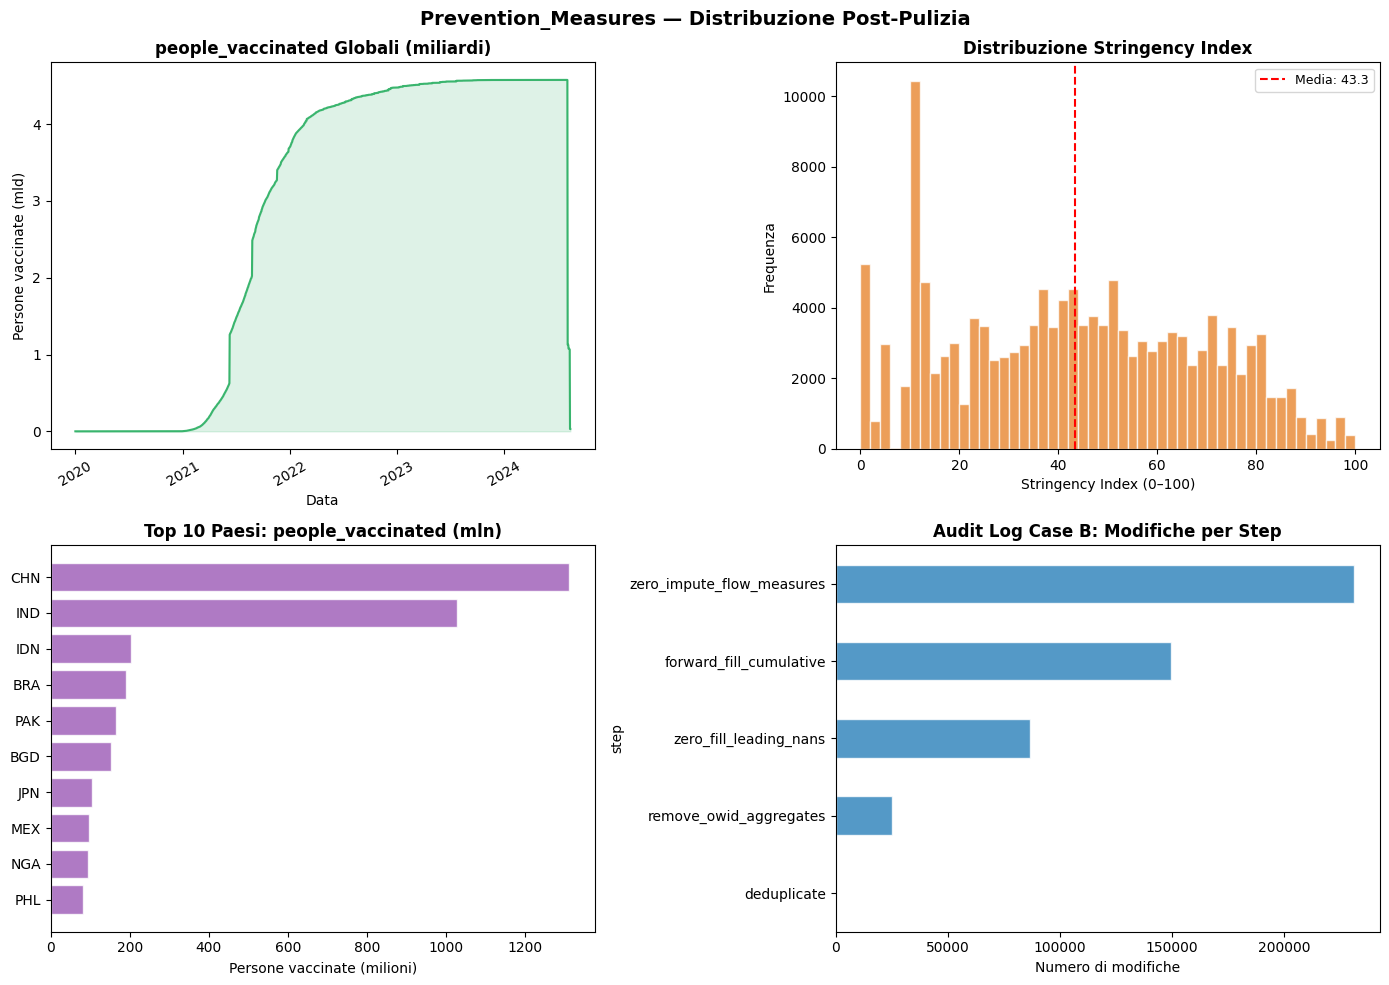

In [19]:
# Grafici di controllo dopo la pulizia di Prevention_Measures
# Visualizzazione distribuzione post-pulizia
clean_prev = pipe_prevention.clean_df

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Prevention_Measures — Distribuzione Post-Pulizia', fontsize=14, fontweight='bold')

# 1. Evoluzione vaccinazioni globali
ax = axes[0, 0]
vacc_col = 'people_vaccinated'
if vacc_col in clean_prev.columns and 'date' in clean_prev.columns:
    daily_vacc = (clean_prev.groupby('date')[vacc_col]
                  .sum()
                  .reset_index()
                  .sort_values('date'))
    ax.plot(daily_vacc['date'], daily_vacc[vacc_col] / 1e9,
            color='#27ae60', linewidth=1.5, alpha=0.9)
    ax.fill_between(daily_vacc['date'], daily_vacc[vacc_col] / 1e9,
                    alpha=0.15, color='#27ae60')
    ax.set_title('people_vaccinated Globali (miliardi)', fontweight='bold')
    ax.set_xlabel('Data')
    ax.set_ylabel('Persone vaccinate (mld)')
    ax.tick_params(axis='x', rotation=30)

# 2. Stringency index: distribuzione
ax = axes[0, 1]
si_col = 'stringency_index'
if si_col in clean_prev.columns:
    vals = clean_prev[si_col].dropna()
    ax.hist(vals, bins=50, color='#e67e22', alpha=0.75, edgecolor='white')
    ax.set_title('Distribuzione Stringency Index', fontweight='bold')
    ax.set_xlabel('Stringency Index (0–100)')
    ax.set_ylabel('Frequenza')
    ax.axvline(vals.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Media: {vals.mean():.1f}')
    ax.legend(fontsize=9)

# 3. Top 10 paesi per people_vaccinated
ax = axes[1, 0]
fv_col = 'people_vaccinated'
if fv_col in clean_prev.columns:
    top10_vacc = (clean_prev.groupby('iso_code')[fv_col]
                  .max()
                  .nlargest(10)
                  .reset_index())
    ax.barh(top10_vacc['iso_code'], top10_vacc[fv_col] / 1e6,
            color='#9b59b6', alpha=0.8, edgecolor='white')
    ax.set_title('Top 10 Paesi: people_vaccinated (mln)', fontweight='bold')
    ax.set_xlabel('Persone vaccinate (milioni)')
    ax.invert_yaxis()

# 4. Audit log Case B
ax = axes[1, 1]
if len(pipe_prevention.audit) > 0:
    audit_sum_b = pipe_prevention.audit.summary().set_index('step')
    audit_sum_b['modifiche'].sort_values().plot(
        kind='barh', ax=ax, color='#2980b9', alpha=0.8, edgecolor='white')
    ax.set_title('Audit Log Case B: Modifiche per Step', fontweight='bold')
    ax.set_xlabel('Numero di modifiche')
else:
    ax.text(0.5, 0.5, 'Nessuna modifica registrata', ha='center', va='center',
            transform=ax.transAxes, fontsize=11)

plt.tight_layout()
plt.savefig(BASE_PATH + 'L3_prevention_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Pulizia Locations (Dimensione)

La tabella `Locations` è una **tabella dimensionale** con una riga per paese.


In [24]:
# PIPELINE Locations: basta togliere OWID_* e deduplicare per iso_code
# Pipeline Locations
print('Avvio pipeline di pulizia: Locations')
print('─' * 55)

pipe_locations = (
    CleaningPipeline(locations_raw, 'Locations', pk_col='iso_code')

    .remove_owid_aggregates(iso_col='iso_code')
    # Rimuovo aggregati OWID_ — non sono paesi reali

    .deduplicate(['iso_code'], keep='first')
    # Garantisce unicità per iso_code (primary key della dimensione)
)

pipe_locations.summary()

# Salvo Locations pulita
pipe_locations.clean_df.to_csv(OUTPUT_LOCATIONS, index=False)
print(f'\n Locations pulita → {OUTPUT_LOCATIONS}')
print(f'   {len(pipe_locations.clean_df)} paesi nella Dim_Location_Context')

# Riepilogo NaN per colonna
loc_clean = pipe_locations.clean_df
nan_summary = loc_clean.isnull().sum()
nan_summary = nan_summary[nan_summary > 0].sort_values(ascending=False)
print(f'\n  Colonne con NaN residui in Locations ({len(nan_summary)} su {len(loc_clean.columns)}):')
if len(nan_summary) > 0:
    print(nan_summary.to_string())


Avvio pipeline di pulizia: Locations
───────────────────────────────────────────────────────
  [remove_owid_aggregates] → 13 righe rimosse con prefisso OWID_
  [deduplicate] → 0 righe duplicate rimosse (da 171 a 171)

 RIEPILOGO PIPELINE — Locations
   Righe originali:  184
   Righe pulite:     171
   Step eseguiti:    2
   Audit entries:    13

                  step  modifiche colonne_modificate
remove_owid_aggregates         13           iso_code

 Locations pulita → /content/drive/MyDrive/Covid-19 Analysis/L3_locations_clean.csv
   171 paesi nella Dim_Location_Context

  Colonne con NaN residui in Locations (5 su 9):
hospital_beds_per_thousand    45
human_development_index       32
gdp_per_capita                29
median_age                    25
population_density            13


##  8. Confronto Qualità Prima/Dopo Pulizia

Calcolo dei punteggi ISO 25012 prima e dopo la pipeline per le tre tabelle.


 CONFRONTO QUALITÀ DATI — PRIMA vs DOPO PULIZIA
══════════════════════════════════════════════════════════════

  📋 Epidemic_Trend
  Dimensione            Prima     Dopo    Delta
  ────────────────────────────────────────
  Completeness         0.9746   0.9966  +0.0220 ⬆️ 
  Uniqueness           0.9825   1.0000  +0.0175 ⬆️ 
  Validity             1.0000   1.0000  +0.0000 ➡️ 

  📋 Prevention_Measures
  Dimensione            Prima     Dopo    Delta
  ────────────────────────────────────────
  Completeness         0.5667   0.8999  +0.3332 ⬆️ 
  Uniqueness           0.9825   1.0000  +0.0175 ⬆️ 
  Validity             1.0000   1.0000  +0.0000 ➡️ 

  📋 Locations
  Dimensione            Prima     Dopo    Delta
  ────────────────────────────────────────
  Completeness         0.8696   0.9064  +0.0368 ⬆️ 
  Uniqueness           1.0000   1.0000  +0.0000 ➡️ 
  Validity             1.0000   1.0000  +0.0000 ➡️ 



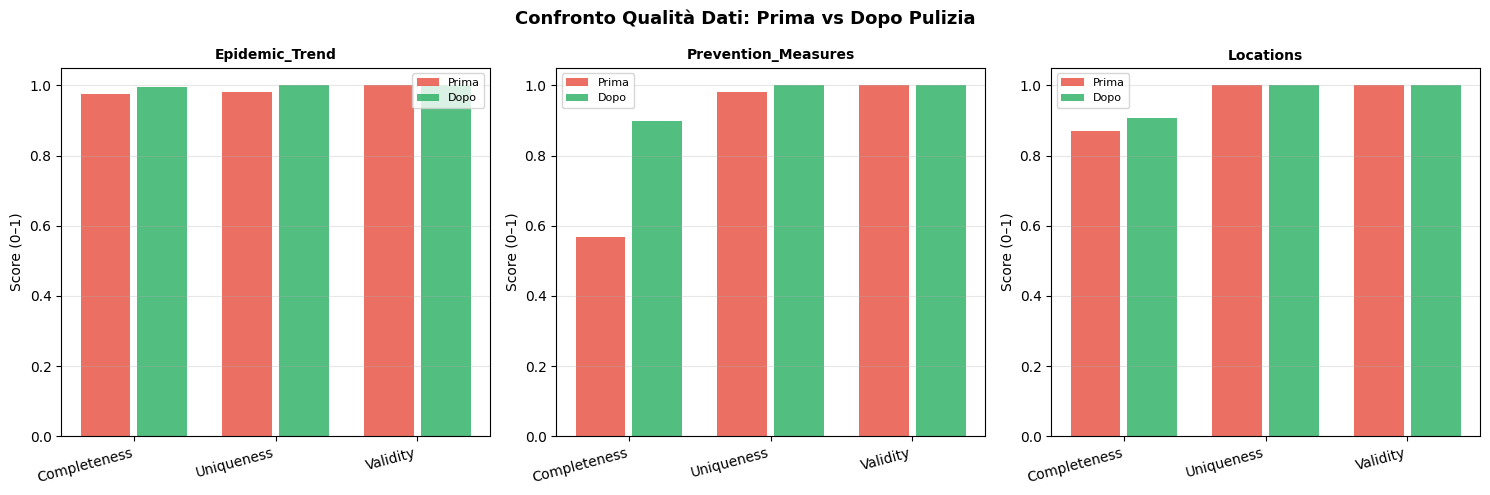

In [21]:
# Confronto i punteggi di qualita (completeness/uniqueness/validity) prima e dopo
def compute_dq_scores(df, pk_cols, flow_cols=None):
    """
    Calcola punteggi DQ semplificati per confronto before/after:
    - Completeness: % celle non nulle
    - Uniqueness:   % righe non duplicate sulla PK
    - Validity:     % valori numerici non negativi nelle misure di flusso
    """
    n_cells = df.shape[0] * df.shape[1]
    completeness = 1 - df.isnull().sum().sum() / n_cells if n_cells > 0 else 0

    if pk_cols:
        uniqueness = 1 - df.duplicated(subset=pk_cols).mean()
    else:
        uniqueness = 1.0

    validity = 1.0
    if flow_cols:
        for col in flow_cols:
            if col in df.columns:
                neg = (df[col].fillna(0) < 0).sum()
                validity -= neg / len(df) / max(len(flow_cols), 1)
        validity = max(validity, 0)

    return {
        'Completeness': round(completeness, 4),
        'Uniqueness':   round(uniqueness, 4),
        'Validity':     round(validity, 4)
    }

# Calcola punteggi
tables = {
    'Epidemic_Trend': {
        'before': epidemic_raw,
        'after':  pipe_epidemic.clean_df,
        'pk':     ['iso_code', 'date'],
        'flow':   ['new_cases', 'new_deaths']
    },
    'Prevention_Measures': {
        'before': prevention_raw,
        'after':  pipe_prevention.clean_df,
        'pk':     ['iso_code', 'date'],
        'flow':   ['new_tests']
    },
    'Locations': {
        'before': locations_raw,
        'after':  pipe_locations.clean_df,
        'pk':     ['iso_code'],
        'flow':   []
    }
}

print(' CONFRONTO QUALITÀ DATI — PRIMA vs DOPO PULIZIA')
print('═' * 62)

all_results = []
for tname, info in tables.items():
    b = compute_dq_scores(info['before'], info['pk'], info['flow'])
    a = compute_dq_scores(info['after'],  info['pk'], info['flow'])
    print(f'\n  📋 {tname}')
    print(f'  {"Dimensione":<18} {"Prima":>8} {"Dopo":>8} {"Delta":>8}')
    print('  ' + '─' * 40)
    for dim in b:
        delta = a[dim] - b[dim]
        arrow = '⬆️ ' if delta > 0.001 else ('⬇️ ' if delta < -0.001 else '➡️ ')
        print(f'  {dim:<18} {b[dim]:>8.4f} {a[dim]:>8.4f} {delta:>+8.4f} {arrow}')
        all_results.append({'Tabella': tname, 'Dimensione': dim,
                             'Prima': b[dim], 'Dopo': a[dim], 'Delta': round(a[dim]-b[dim],4)})

print()

# Grafico confronto
results_df = pd.DataFrame(all_results)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Confronto Qualità Dati: Prima vs Dopo Pulizia', fontsize=13, fontweight='bold')

for i, (tname, info) in enumerate(tables.items()):
    ax = axes[i]
    subset = results_df[results_df['Tabella'] == tname]
    dims = subset['Dimensione'].tolist()
    x = np.arange(len(dims))
    ax.bar(x - 0.2, subset['Prima'], 0.35, label='Prima', color='#e74c3c', alpha=0.8)
    ax.bar(x + 0.2, subset['Dopo'],  0.35, label='Dopo',  color='#27ae60', alpha=0.8)
    ax.set_title(tname, fontweight='bold', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(dims, rotation=15, ha='right')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score (0–1)')
    ax.legend(fontsize=8)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(BASE_PATH + 'L3_dq_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 🎯 9. Riepilogo e Principi Guida

✅ :
   1. AuditLog         — ogni modifica cella per cella tracciata con before/after e motivazione
   2. CleaningPipeline — step modulari concatenabili, riproducibili
   3. Case A (Epidemic_Trend)      — zero-imputation per misure di flusso (MCAR)
   4. Case B (Prevention_Measures) — forward-fill cumulativi (MAR) e zero-fill leading NaN (MNAR)
   5. Locations         — rimozione OWID_ e deduplicazione
   6. Confronto DQ      — punteggi ISO 25012 prima/dopo per 3 tabelle

📌 Principi di design DW cleaning:
   • Immutabilità del dato grezzo: non sovrascrivere mai i dati originali
   • Logga tutto
   • MCAR → zero-impute per flussi (new_cases, new_deaths)
   • MAR  → forward-fill per cumulativi (people_vaccinated)
   • MNAR → zero-fill + documentazione esplicita (dati pre-vaccino)
   • I picchi epidemici (es. Omicron 2022) sono segnali reali, non outlier
   • Deduplica per ultima: pulire prima migliora la qualità del match


### Output prodotti:
| File | Contenuto |
|------|-----------|
| `L3_epidemic_trend_clean.csv` | Epidemic_Trend pulita (pronta per ETL) |
| `L3_prevention_measures_clean.csv` | Prevention_Measures pulita |
| `L3_locations_clean.csv` | Locations pulita (dimensione) |
| `L3_epidemic_audit_log.csv` | Audit log dettagliato Case A |
| `L3_prevention_audit_log.csv` | Audit log dettagliato Case B |
| `L3_epidemic_audit_summary.csv` | Riepilogo step Case A |
| `L3_prevention_audit_summary.csv` | Riepilogo step Case B |
| `L3_epidemic_analysis.png` | Grafici distribuzione Case A |
| `L3_prevention_analysis.png` | Grafici distribuzione Case B |
| `L3_dq_comparison.png` | Confronto qualità prima/dopo |

**Prossimo step (L4):** Modellazione dimensionale — Attribute Tree, Star Schema, DDL MySQL
